<a href="https://colab.research.google.com/github/Laxmi05-01-2006/My-New-Project/blob/main/Clustering_2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score



In [3]:
from google.colab import files
uploaded = files.upload()

Saving diabetic_data.csv to diabetic_data.csv


In [4]:
df = pd.read_csv("diabetic_data.csv")


In [5]:
print("First 5 Rows")
print(df.head())

First 5 Rows
   encounter_id  patient_nbr             race  gender      age weight  \
0       2278392      8222157        Caucasian  Female   [0-10)      ?   
1        149190     55629189        Caucasian  Female  [10-20)      ?   
2         64410     86047875  AfricanAmerican  Female  [20-30)      ?   
3        500364     82442376        Caucasian    Male  [30-40)      ?   
4         16680     42519267        Caucasian    Male  [40-50)      ?   

   admission_type_id  discharge_disposition_id  admission_source_id  \
0                  6                        25                    1   
1                  1                         1                    7   
2                  1                         1                    7   
3                  1                         1                    7   
4                  1                         1                    7   

   time_in_hospital  ... citoglipton insulin  glyburide-metformin  \
0                 1  ...          No      No        

In [6]:
print("\nDataset Shape")
print(df.shape)




Dataset Shape
(101766, 50)


In [7]:
print("\nMissing Values")
print(df.isnull().sum())



Missing Values
encounter_id                    0
patient_nbr                     0
race                            0
gender                          0
age                             0
weight                          0
admission_type_id               0
discharge_disposition_id        0
admission_source_id             0
time_in_hospital                0
payer_code                      0
medical_specialty               0
num_lab_procedures              0
num_procedures                  0
num_medications                 0
number_outpatient               0
number_emergency                0
number_inpatient                0
diag_1                          0
diag_2                          0
diag_3                          0
number_diagnoses                0
max_glu_serum               96420
A1Cresult                   84748
metformin                       0
repaglinide                     0
nateglinide                     0
chlorpropamide                  0
glimepiride                     

In [8]:
for col in df.columns:
    if df[col].dtype == 'object':
        df[col] = df[col].fillna(df[col].mode()[0])
    else:
        df[col] = df[col].fillna(df[col].median())


In [10]:
label_encoder = LabelEncoder()

for col in df.columns:
    if df[col].dtype == 'object':
        df[col] = label_encoder.fit_transform(df[col].astype(str))



In [11]:
scaler = StandardScaler()
scaled_data = scaler.fit_transform(df)


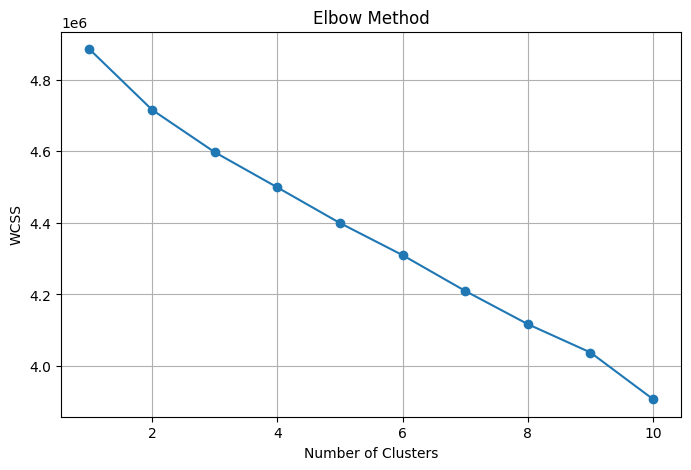

In [12]:
wcss = []

for i in range(1,11):
    kmeans = KMeans(
        n_clusters=i,
        random_state=42,
        n_init=10
    )
    kmeans.fit(scaled_data)
    wcss.append(kmeans.inertia_)

plt.figure(figsize=(8,5))
plt.plot(range(1,11), wcss, marker='o')
plt.title("Elbow Method")
plt.xlabel("Number of Clusters")
plt.ylabel("WCSS")
plt.grid(True)
plt.show()

In [14]:
kmeans = KMeans(
    n_clusters=3,
    random_state=42,
    n_init=10
)

clusters = kmeans.fit_predict(scaled_data)

df['Cluster'] = clusters

print("\nCluster Counts")
print(df['Cluster'].value_counts())


Cluster Counts
Cluster
2    49388
0    44042
1     8336
Name: count, dtype: int64


In [15]:
score = silhouette_score(scaled_data, clusters)

print("\nSilhouette Score =", score)



Silhouette Score = 0.044949762158670456


In [16]:
pca = PCA(n_components=2)

pca_data = pca.fit_transform(scaled_data)

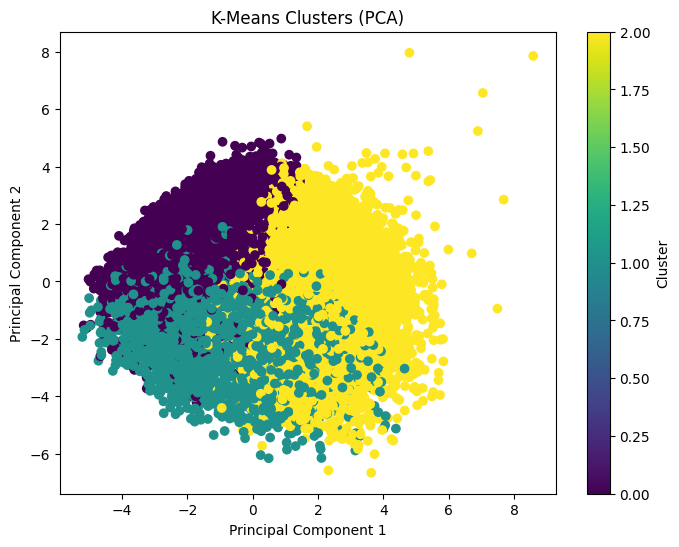

In [17]:
plt.figure(figsize=(8,6))

plt.scatter(
    pca_data[:,0],
    pca_data[:,1],
    c=clusters,
    cmap='viridis'
)

plt.title("K-Means Clusters (PCA)")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.colorbar(label="Cluster")
plt.show()


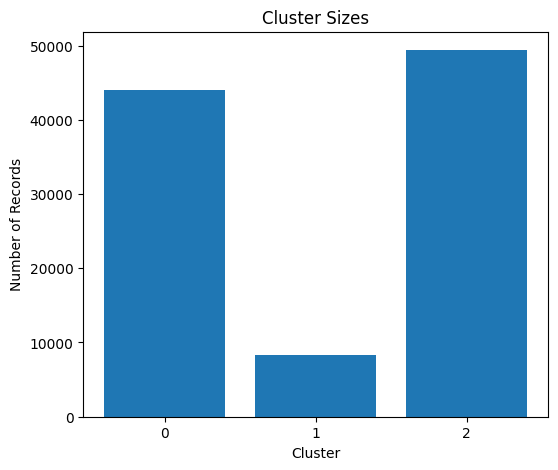

In [18]:
cluster_counts = df['Cluster'].value_counts().sort_index()

plt.figure(figsize=(6,5))

plt.bar(cluster_counts.index.astype(str), cluster_counts.values)

plt.title("Cluster Sizes")
plt.xlabel("Cluster")
plt.ylabel("Number of Records")
plt.show()

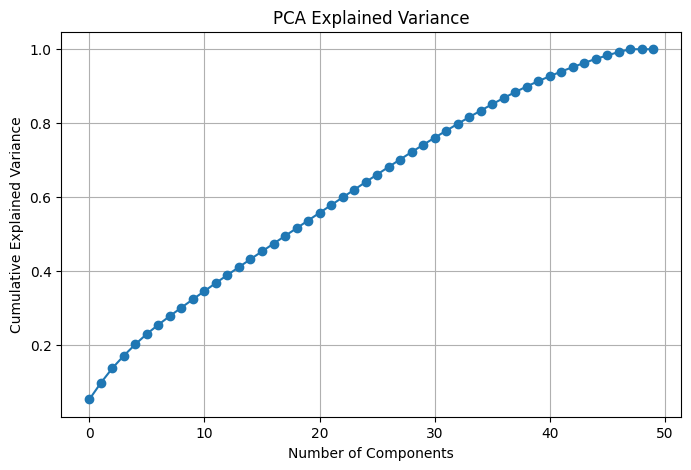

In [19]:
pca_full = PCA()

pca_full.fit(scaled_data)

plt.figure(figsize=(8,5))

plt.plot(
    np.cumsum(pca_full.explained_variance_ratio_),
    marker='o'
)

plt.xlabel("Number of Components")
plt.ylabel("Cumulative Explained Variance")
plt.title("PCA Explained Variance")
plt.grid(True)
plt.show()

In [20]:
df.to_csv("diabetic_clustered_output.csv", index=False)

print("\nClustered dataset saved successfully!")


Clustered dataset saved successfully!
